In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Business Task

<p style="text-align: justify">
Cyclistic is a bike-share company that has expanded to a fleet of 5,824 bicycles, geotracked and distributed across 692 stations in Chicago. What sets Cyclistic apart is its inclusive offering of reclining bikes, hand tricycles, and cargo bikes, making bike-share accessible to people with disabilities and riders who cannot use a standard two-wheeled bike. Customers can unlock a bike at one station and return it to any other station in the system at any time.
</p>

<p style="text-align: justify">
Cyclistic’s growth has been supported by flexible pricing plans, including single-ride passes, full-day passes, and annual memberships. To better understand customer behavior, riders are segmented into two groups: casual riders, who purchase single-ride or day passes, and members, who commit to annual memberships.
</p>

<p style="text-align: justify">
An analysis by the finance team revealed a significant difference in profitability between these two groups. Based on this insight, the company believes there is strong potential to convert casual riders into members. Therefore, the goal of this analysis is to understand how casual riders and annual members use Cyclistic bikes differently. By analyzing historical trip data, we aim to identify behavioral patterns across the two groups and generate insights that can help the marketing team design strategies to convert casual riders into annual members. The analysis will focus on ride frequency, trip duration, time-of-day usage, and seasonal patterns.
</p>



# Data Preparation


## Data Source
<p style="text-align:justify">
The datasets used in this case study were obtained from Divvy's public trip data repository:
https://divvy-tripdata.s3.amazonaws.com/index.html
</p>
<p style="text-align:justify">
These files contain Cyclistic's historical trip records including ride duration, rider type, start and end times, and station details. The data was made available for analysis as part of the case study and is used to identify differences between casual riders and annual members.
</p>

## Data Licensing and Accessibility
<p style="text-align:justify">
The data is publicly available under Divvy's Data License Agreement:
https://divvybikes.com/data-license-agreement
</p>
<p style="text-align:justify">
According to the license, the data can be accessed and analyzed for lawful purposes, including use in analyses, reports, or studies for non-commercial purposes. However, the data is provided "as is," which means accuracy, completeness, and availability are not guaranteed.
</p>

## Data Organization
<p style="text-align:justify">
The data is organized in tabular format, with each row representing one bike trip and each column representing a trip attribute such as ride ID, bike type, start time, end time, start station, end station, and member status. Because the data is provided across multiple files, it may need to be combined before analysis.
</p>

## Data Credibility and Bias
<p style="text-align:justify">
The dataset is relevant to the business problem because it contains real trip behavior for both casual riders and members. However, it has some limitations. It does not include personal demographic information, customer motivations, or direct feedback, so conclusions can only be based on trip behavior. In addition, the data may contain missing values, inconsistent station names, or other quality issues that need to be addressed before analysis.
</p>

## Data Integrity
<p style="text-align:justify">
To verify the integrity of the data, the files will be inspected for missing values, duplicate records, incorrect data types, and inconsistent formatting. Column names and data structures will also be reviewed to ensure the datasets can be merged and analyzed correctly.
</p>

## Data Limitations
<p style="text-align:justify">
Although the data is useful for identifying usage patterns, it may not fully explain why casual riders choose not to become members. This means the analysis can support recommendations, but it cannot directly measure customer intent or preferences.
</p>

In [2]:
divvy_trips_19 = pd.read_csv("Divvy_Trips_2019_Q1.csv")
divvy_trips_20 = pd.read_csv("Divvy_Trips_2020_Q1.csv")

In [3]:
divvy_trips_19.head()

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390.0,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441.0,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829.0,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,"1,783.0",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364.0,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0


In [4]:
divvy_trips_20.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,41.9671,-87.6674,member
1,8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,41.9542,-87.6644,member
2,789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117.0,41.9401,-87.6455,41.9402,-87.6530,member
3,C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24.0,41.8846,-87.6319,41.8918,-87.6206,member
4,943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212.0,41.8856,-87.6418,41.8899,-87.6343,member


In [5]:
print('2019 Trips Column Names: \n-------------------------')
print(list(divvy_trips_19.columns), end=' ')

2019 Trips Column Names: 
-------------------------
['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration', 'from_station_id', 'from_station_name', 'to_station_id', 'to_station_name', 'usertype', 'gender', 'birthyear'] 

In [6]:
print('2020 Trips Column Names: \n-------------------------')
print(list(divvy_trips_20.columns), end=' ')

2020 Trips Column Names: 
-------------------------
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual'] 

<p style="text-align:justify">
The datasets contain inconsistent column names across years, which requires standardization before they can be combined. This step ensures consistency and enables accurate analysis across both datasets.
</p>


In [7]:
divvy_trips_19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   trip_id            365069 non-null  int64  
 1   start_time         365069 non-null  object 
 2   end_time           365069 non-null  object 
 3   bikeid             365069 non-null  int64  
 4   tripduration       365069 non-null  object 
 5   from_station_id    365069 non-null  int64  
 6   from_station_name  365069 non-null  object 
 7   to_station_id      365069 non-null  int64  
 8   to_station_name    365069 non-null  object 
 9   usertype           365069 non-null  object 
 10  gender             345358 non-null  object 
 11  birthyear          347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB


In [8]:
divvy_trips_20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  object 
 1   rideable_type       426887 non-null  object 
 2   started_at          426887 non-null  object 
 3   ended_at            426887 non-null  object 
 4   start_station_name  426887 non-null  object 
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  object 
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non-null  float64
 11  end_lng             426886 non-null  float64
 12  member_casual       426887 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 42.3+ MB


In [9]:
missing_values = pd.DataFrame({
    'missing_count': divvy_trips_19.isna().sum(),
    'missing_percentage': divvy_trips_19.isna().sum() / len(divvy_trips_19) * 100,
})

missing_values.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percentage
gender,19711,5.399253
birthyear,18023,4.936875
trip_id,0,0.000000
start_time,0,0.000000
bikeid,0,0.000000
end_time,0,0.000000
tripduration,0,0.000000
from_station_id,0,0.000000
to_station_id,0,0.000000
from_station_name,0,0.000000


In [10]:
missing_values_2 = pd.DataFrame({
    'missing_count': divvy_trips_20.isna().sum(),
    'missing_percentage': divvy_trips_20.isna().sum() / len(divvy_trips_20) * 100,
})

missing_values_2.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percentage
end_station_name,1,0.000234
end_lat,1,0.000234
end_lng,1,0.000234
end_station_id,1,0.000234
ride_id,0,0.000000
start_station_name,0,0.000000
ended_at,0,0.000000
started_at,0,0.000000
rideable_type,0,0.000000
start_lat,0,0.000000


<p style="text-align:justify">
The 2019 Divvy trips dataset contains missing values in the `gender` and `birthyear` fields, affecting approximately 5% and 4% of the records, respectively. An appropriate approach to handling these missing values will be evaluated during the data cleaning process.
</p>

In [11]:
divvy_trips_19.duplicated().sum()

np.int64(0)

In [12]:
divvy_trips_20.duplicated().sum()

np.int64(0)

<p style="text-align:justify">
Fortunately no fully duplicated rows were found in both datasets. This suggests that duplicate records are not a major data quality issue at this stage.
</p>

# Data Cleaning and Transformation

In [13]:
df_2019 = divvy_trips_19.copy()
df_2020 = divvy_trips_20.copy()

In [14]:
column_names = {
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_name': 'start_station_name',
    'from_station_id': 'start_station_id',
    'to_station_name': 'end_station_name',
    'to_station_id': 'end_station_id',
    'usertype': 'member_casual'
}

In [15]:
df_2019 = df_2019.rename(columns = column_names)

In [16]:
df_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             365069 non-null  int64  
 1   started_at          365069 non-null  object 
 2   ended_at            365069 non-null  object 
 3   bikeid              365069 non-null  int64  
 4   tripduration        365069 non-null  object 
 5   start_station_id    365069 non-null  int64  
 6   start_station_name  365069 non-null  object 
 7   end_station_id      365069 non-null  int64  
 8   end_station_name    365069 non-null  object 
 9   member_casual       365069 non-null  object 
 10  gender              345358 non-null  object 
 11  birthyear           347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB


In [17]:
df_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  object 
 1   rideable_type       426887 non-null  object 
 2   started_at          426887 non-null  object 
 3   ended_at            426887 non-null  object 
 4   start_station_name  426887 non-null  object 
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  object 
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non-null  float64
 11  end_lng             426886 non-null  float64
 12  member_casual       426887 non-null  object 
dtypes: float64(5), int64(1), object(7)
memory usage: 42.3+ MB


In [18]:
df_2019['ride_id'] = df_2019['ride_id'].astype(str)

In [19]:
df_2019['member_casual'].unique()

array(['Subscriber', 'Customer'], dtype=object)

In [20]:
df_2020['member_casual'].unique()

array(['member', 'casual'], dtype=object)

In [21]:
df_2019['member_casual'] = df_2019['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

In [22]:
df_2019['member_casual'].unique()

array(['member', 'casual'], dtype=object)

In [23]:
df_2019['started_at'] = pd.to_datetime(df_2019['started_at'])
df_2019['ended_at'] = pd.to_datetime(df_2019['ended_at'])
df_2020['started_at'] = pd.to_datetime(df_2020['started_at'])
df_2020['ended_at'] = pd.to_datetime(df_2020['ended_at'])

In [24]:
common_columns = [
    'ride_id',
    'started_at',
    'ended_at',
    'start_station_name',
    'start_station_id',
    'end_station_name',
    'end_station_id',
    'member_casual'
]

In [25]:
df_2019_clean = df_2019[common_columns].copy()
df_2020_clean = df_2020[common_columns].copy()

In [26]:
all_trips = pd.concat([df_2019_clean, df_2020_clean], ignore_index=True)

In [27]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791956 non-null  object        
 1   started_at          791956 non-null  datetime64[ns]
 2   ended_at            791956 non-null  datetime64[ns]
 3   start_station_name  791956 non-null  object        
 4   start_station_id    791956 non-null  int64         
 5   end_station_name    791955 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   member_casual       791956 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 48.3+ MB


In [28]:
all_trips[all_trips.isnull().any(axis=1)]

,ride_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual
779495,157EAA4C4A3C8D36,2020-03-16 11:23:36,2020-03-16 11:23:24,HQ QR,675,NaN,NaN,casual


In [29]:
all_trips.dropna(inplace=True)

In [30]:
all_trips['ride_length'] = (all_trips['ended_at']-all_trips['started_at']).dt.total_seconds()/60


In [31]:
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()
all_trips['month'] = all_trips['started_at'].dt.month_name()

## Feature Engineering

New variables were created to support time-based analysis and better understand rider behavior.

- `ride_length`: calculated as the duration of each trip in minutes
- `day_of_week`: extracted from the trip start time to analyze weekly patterns
- `month`: extracted from the start time to identify potential seasonal trends

In [32]:
all_trips.head()

,ride_id,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,ride_length,day_of_week,month
0,21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,Wabash Ave & Grand Ave,199,Milwaukee Ave & Grand Ave,84.0,member,6.500000,Tuesday,January
1,21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,State St & Randolph St,44,Dearborn St & Van Buren St (*),624.0,member,7.350000,Tuesday,January
2,21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,Racine Ave & 18th St,15,Western Ave & Fillmore St (*),644.0,member,13.816667,Tuesday,January
3,21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,California Ave & Milwaukee Ave,123,Clark St & Elm St,176.0,member,29.716667,Tuesday,January
4,21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,Mies van der Rohe Way & Chicago Ave,173,Streeter Dr & Grand Ave,35.0,member,6.066667,Tuesday,January


In [33]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
Index: 791955 entries, 0 to 791955
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791955 non-null  object        
 1   started_at          791955 non-null  datetime64[ns]
 2   ended_at            791955 non-null  datetime64[ns]
 3   start_station_name  791955 non-null  object        
 4   start_station_id    791955 non-null  int64         
 5   end_station_name    791955 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   member_casual       791955 non-null  object        
 8   ride_length         791955 non-null  float64       
 9   day_of_week         791955 non-null  object        
 10  month               791955 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(6)
memory usage: 72.5+ MB


In [34]:
all_trips['member_casual'].value_counts()

member_casual
member    720313
casual     71642
Name: count, dtype: int64

In [35]:
all_trips['ride_length'].describe()

count    791955.000000
mean         19.730246
std         553.546036
min          -9.200000
25%           5.466667
50%           8.950000
75%          15.166667
max      177200.366667
Name: ride_length, dtype: float64

In [39]:
all_trips = all_trips[(all_trips['ride_length'] > 0) & (all_trips['ride_length'] <= 10080)].copy()

In [40]:
all_trips['ride_length'].describe()

count    791650.000000
mean         15.248591
std          89.791174
min           0.016667
25%           5.466667
50%           8.950000
75%          15.150000
max       10017.233333
Name: ride_length, dtype: float64

- Python (pandas) was used to clean, transform, and combine the datasets from 2019 and 2020.

- Column names in the 2019 dataset were standardized to match the 2020 schema, ensuring consistency across both sources.

- User type values in 2019 (`Subscriber` / `Customer`) were mapped to `member` / `casual` to enable direct comparison.

- Only columns shared by both datasets were retained to ensure comparability. The `rideable_type` column was excluded because it showed no variation in 2020 and was not consistent across datasets.

- Date columns were converted to datetime format to support accurate time-based analysis, and a new variable (`ride_length`) was created from trip start and end timestamps.

- The two quarterly datasets were merged into a single dataframe for unified analysis.

- Data quality checks were performed:
  - No duplicate rows were found
  - Trips with non-positive durations were removed, as they are invalid
  - Trips longer than one week were excluded, as they likely represent data-entry or operational anomalies
  - Trips between 24 hours and 7 days were retained, as extended use may still be plausible

- Fields such as `gender` and `birthyear` were excluded from the analysis, as they are not present in the 2020 dataset and are not required to address the business objective.

# Exploratory Data Analysis

## Who generates more rides: casual riders or members?
<p style="text-align:justify">
Understanding the distribution of total rides by user type helps identify which group contributes most to overall usage and where conversion opportunities may exist.
</p>

In [42]:
all_trips_percentaje = all_trips.groupby('member_casual').agg(Total_rides=('ride_length', 'count')).reset_index()
all_trips_percentaje['% Total of rides'] = all_trips_percentaje['Total_rides']/all_trips_percentaje['Total_rides'].sum() *100
all_trips_percentaje['% Total of rides'] = all_trips_percentaje['% Total of rides'].map('{:.2f}%'.format)
all_trips_percentaje

,member_casual,Total_rides,% Total of rides
0,casual,71364,9.01%
1,member,720286,90.99%


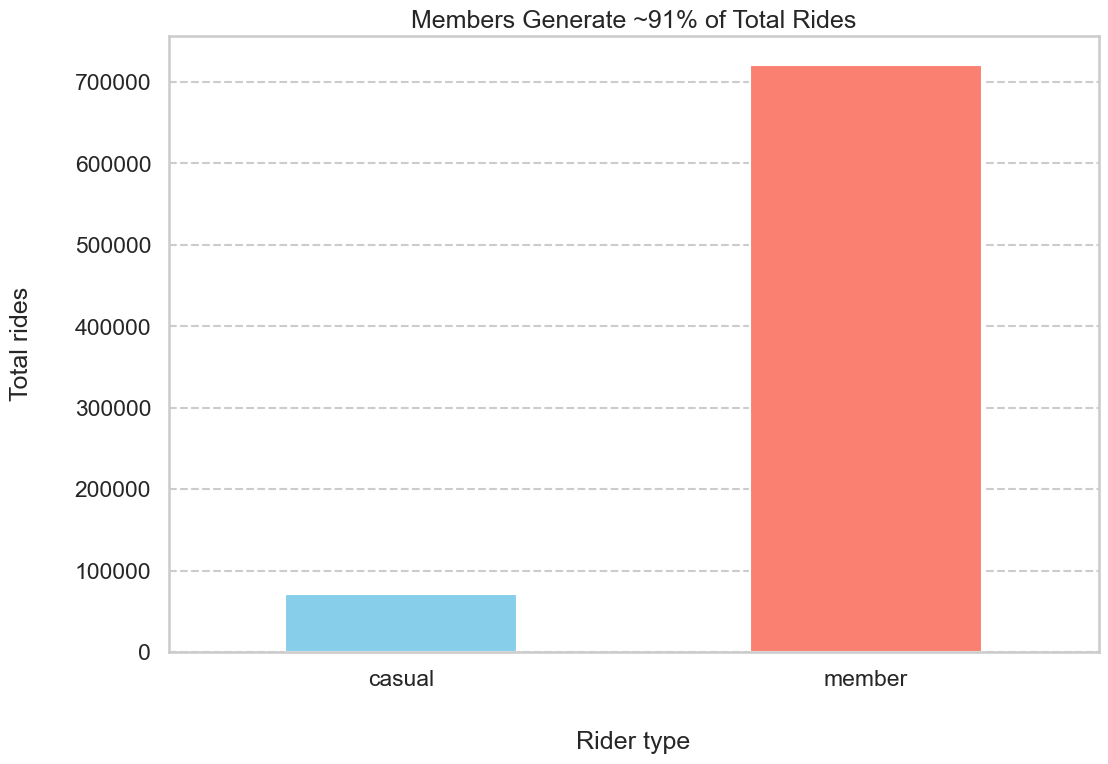

In [74]:
fig, ax = plt.subplots(figsize=(12, 8))
all_trips_percentaje.plot(
    kind='bar',
    x='member_casual',
    y='Total_rides',
    color=['skyblue', 'salmon'],
    legend=False,
    ax=ax
)
plt.title('Members Generate ~91% of Total Rides')
plt.xlabel('Rider type', labelpad=30)
plt.ylabel('Total rides', labelpad=30)
plt.grid(axis= 'y', linestyle='--')
plt.gca().xaxis.grid(False)
plt.xticks(rotation=0)
plt.savefig("./images/total_rides_by_rider_type.png", bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

Members account for approximately 91% of total rides, indicating that they are the primary contributors to overall usage and represent more consistent, habitual users.


In contrast, casual riders contribute only around 9% of total rides, highlighting a significant opportunity to increase revenue by converting these users into members.

## Do casual riders take longer trips than members?

Casual riders are expected to have longer ride durations, indicating a preference for leisure-oriented usage compared to members.

In [41]:
agg_data = all_trips.groupby('member_casual')['ride_length'].agg(['count', 'mean', 'median', 'max', 'min']).reset_index()
agg_data

,member_casual,count,mean,median,max,min
0,casual,71364,48.032755,22.041667,10017.233333,0.016667
1,member,720286,12.000425,8.466667,8645.033333,0.016667


<Figure size 1200x800 with 0 Axes>

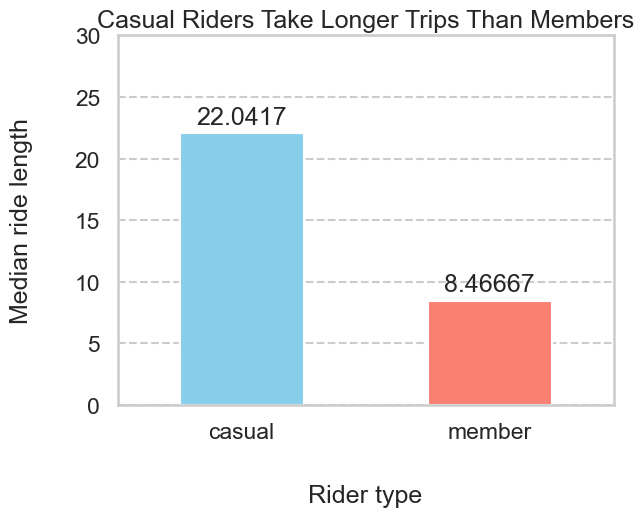

In [76]:
plt.figure(figsize=(12, 8))
ax = agg_data.plot(
    kind='bar',
    x='member_casual',
    y='median',
    legend=False,
    color=['skyblue', 'salmon']
)
plt.title('Casual Riders Take Longer Trips Than Members')
plt.xlabel('Rider type', labelpad=30)
plt.ylabel('Median ride length', labelpad=30)
plt.grid(axis='y', linestyle='--')
plt.gca().xaxis.grid(False)
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=0)
plt.ylim(0, 30)
plt.savefig("./images/median_ride_length_by_rider_type.png", bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

Casual riders exhibit significantly longer median ride durations than members, reinforcing the idea that they use the service primarily for leisure rather than routine commuting.

This behavior suggests that casual riders may be more sensitive to per-ride costs, creating an opportunity to position memberships as a cost-effective option for longer trips.

## How does riding behavior differ between weekdays and weekends?

Casual riders are expected to concentrate their usage on weekends, while members are more likely to ride consistently during weekdays due to commuting patterns.

In [43]:
all_trips.groupby(['member_casual', 'day_of_week'])['ride_length'].agg(['count', 'mean', 'median', 'max', 'min'])

count       mean     median           max  \
member_casual day_of_week                                               
casual        Friday         8498  45.468916  18.816667   8591.983333   
              Monday         6689  41.895797  15.833333   9640.500000   
              Saturday      13457  48.579312  24.216667   7674.966667   
              Sunday        18638  53.897471  26.766667  10017.233333   
              Thursday       7761  48.994264  18.483333   9777.816667   
              Tuesday        7964  38.779345  17.891667   7519.533333   
              Wednesday      8357  49.517486  21.616667   8156.366667   
member        Friday       115162  11.760509   8.200000   5266.233333   
              Monday       110425  11.347941   8.383333   3000.700000   
              Saturday      59408  13.722412   8.750000   7586.700000   
              Sunday        60192  13.687966   9.133333   8645.033333   
              Thursday     125226  11.604727   8.366667   7781.116667   
              Tuesday      127971  11.787797   8.483333   7334.483333   
              Wednesday    121902  11.775367   8.450000   8069.866667   

                                min  
member_casual day_of_week            
casual        Friday       0.016667  
              Monday       0.016667  
              Saturday     0.050000  
              Sunday       0.050000  
              Thursday     0.016667  
              Tuesday      0.016667  
              Wednesday    0.016667  
member        Friday       0.016667  
              Monday       0.033333  
              Saturday     0.016667  
              Sunday       0.033333  
              Thursday     0.016667  
              Tuesday      0.033333  
              Wednesday    0.033333

In [77]:
ride_by_day = all_trips.groupby(['member_casual', 'day_of_week']).size().reset_index(name='rides_count')
total_rides_by_type = ride_by_day.groupby('member_casual')['rides_count'].transform('sum')
ride_by_day['percentage_within_group'] = (ride_by_day['rides_count']/total_rides_by_type)*100

In [78]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ride_by_day['day_of_week'] = pd.Categorical(
    ride_by_day['day_of_week'],
    categories=day_order,
    ordered=True
)
ride_by_day = ride_by_day.sort_values(['member_casual', 'day_of_week'])
ride_by_day

,member_casual,day_of_week,rides_count,percentage_within_group
1,casual,Monday,6689,9.373073
5,casual,Tuesday,7964,11.159688
6,casual,Wednesday,8357,11.710386
4,casual,Thursday,7761,10.875231
0,casual,Friday,8498,11.907965
2,casual,Saturday,13457,18.856847
3,casual,Sunday,18638,26.116810
8,member,Monday,110425,15.330716
12,member,Tuesday,127971,17.766693
13,member,Wednesday,121902,16.924111


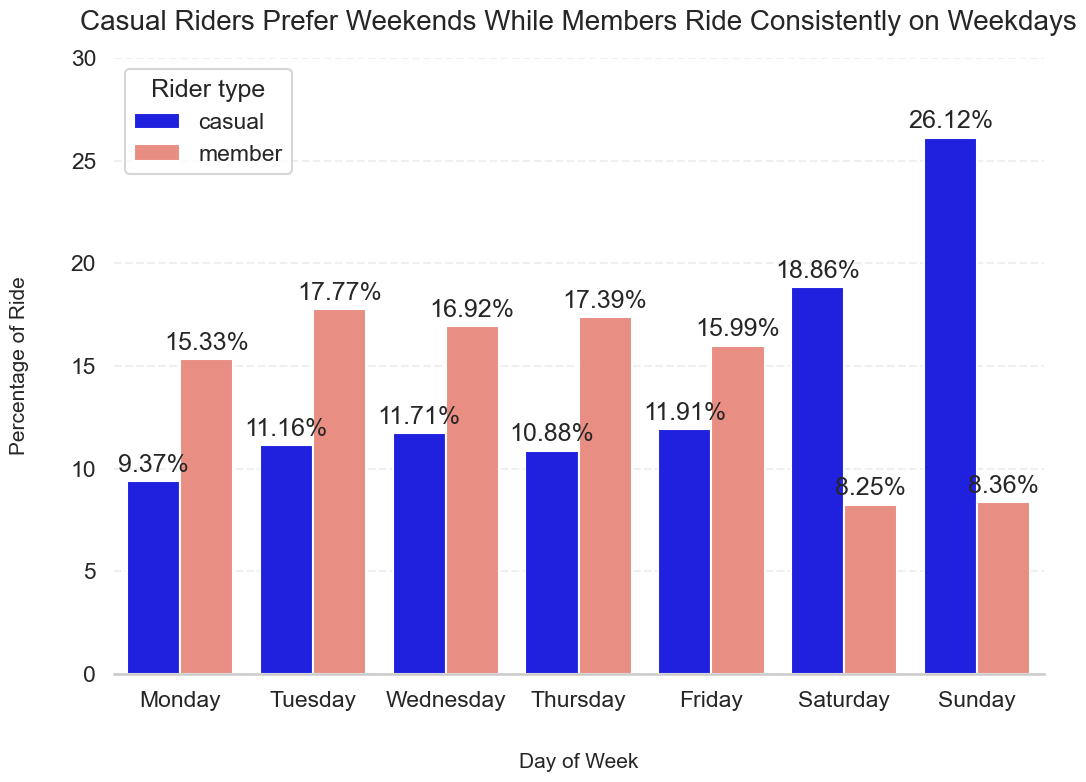

In [80]:
plt.figure(figsize=(12, 8))
sns.set_theme(style='whitegrid', context='talk', palette='pastel')
ax = sns.barplot(data=ride_by_day, x='day_of_week', y='percentage_within_group', hue='member_casual', palette=['blue', 'salmon'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Casual Riders Prefer Weekends While Members Ride Consistently on Weekdays', fontsize=20, pad=20)
plt.xlabel('Day of Week', labelpad=30, fontsize=15)
plt.ylabel('Percentage of Ride', labelpad=30, fontsize=15)
plt.legend(title='Rider type', loc='upper left')
plt.ylim(0,30)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.savefig("./images/rides_by_day_of_week.png", bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

Casual riders show a clear concentration of trips on weekends, particularly on Saturday and Sunday, indicating a strong preference for leisure and recreational use.

In contrast, members display a more balanced distribution across weekdays, suggesting consistent usage aligned with commuting and daily transportation needs.

This contrast highlights a key segmentation opportunity: casual riders can be targeted during weekends, when engagement is highest, to increase the likelihood of membership conversion.

## Are there monthly trends in riding behavior?

Analyzing ride distribution across months helps identify potential seasonal patterns and changes in user activity over time.

In [46]:
all_trips.groupby(['member_casual', 'month'])['ride_length'].agg(['count', 'mean', 'median', 'max', 'min'])

count       mean     median           max       min
member_casual month                                                         
casual        February   15473  49.978704  20.000000   9508.316667  0.016667
              January    12365  51.566952  18.816667   9777.816667  0.033333
              March      43526  46.336986  23.750000  10017.233333  0.016667
member        February  220254  11.469652   8.183333   8645.033333  0.016667
              January   234759  11.954108   8.266667   8069.866667  0.033333
              March     265273  12.482110   8.916667   6683.383333  0.016667

In [81]:
ride_by_month = all_trips.groupby(['member_casual', 'month']).size().reset_index(name='rides_count')
total_rides_by_month = ride_by_month.groupby('member_casual')['rides_count'].transform('sum')
ride_by_month['percentage_within_group'] = (ride_by_month['rides_count']/total_rides_by_month)*100

In [82]:
month_order = ['January', 'February', 'March']
ride_by_month['month'] = pd.Categorical(
    ride_by_month['month'],
    categories=month_order,
    ordered=True
)
ride_by_month = ride_by_month.sort_values(['member_casual', 'month'])
ride_by_month

,member_casual,month,rides_count,percentage_within_group
1,casual,January,12365,17.326663
0,casual,February,15473,21.681800
2,casual,March,43526,60.991536
4,member,January,234759,32.592470
3,member,February,220254,30.578687
5,member,March,265273,36.828843


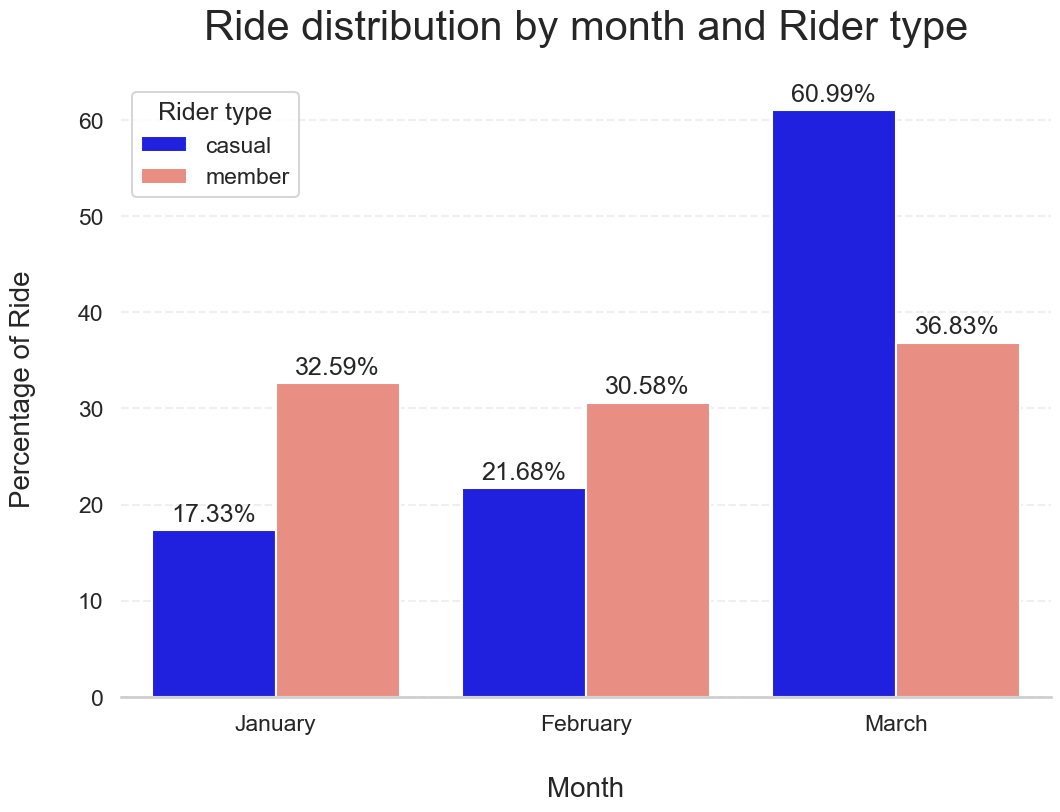

In [73]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=ride_by_month_plot,
    x='month',
    y='percentage_within_group',
    hue='member_casual',
    palette=['blue', 'salmon']
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Ride distribution by month and Rider type', fontsize=30, pad=30)
plt.xlabel('Month', labelpad=30, fontsize=20)
plt.ylabel('Percentage of Ride', labelpad=30, fontsize=20)
plt.legend(title='Rider type', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.savefig("./images/rides_by_month.png", bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

Both casual riders and members show an increase in ride activity from January to March, with March representing the highest share of rides for both groups.

This upward trend suggests a seasonal effect, where usage increases as weather conditions improve toward the end of the quarter.

However, since the analysis is limited to Q1 data, this pattern should be validated with additional months to confirm full seasonal trends.

## Summary Analysis

The analysis reveals clear behavioral differences between casual riders and members. Members generate the majority of total rides and exhibit consistent weekday usage, indicating reliance on the service for routine transportation and commuting.

In contrast, casual riders take longer trips and concentrate their usage on weekends, suggesting a preference for leisure and recreational use rather than daily mobility.

Additionally, ride activity increases from January to March for both user groups, indicating a potential seasonal pattern. However, since the analysis is limited to first-quarter data, further investigation across additional months is required to confirm this trend.

These behavioral differences highlight a strong opportunity to design targeted strategies aimed at converting casual riders into members by aligning marketing efforts with their usage patterns.

By targeting casual riders during high-engagement periods and emphasizing the value of membership for longer trips, Cyclistic can increase conversion rates and drive more stable, recurring revenue.

## Key Findings

- Members account for the majority of total rides, indicating strong adoption among frequent users and consistent usage patterns.

- Casual riders exhibit longer median ride durations, suggesting a preference for leisure-oriented trips rather than routine transportation.

- Casual riders concentrate a higher share of their trips on weekends, while members show more consistent weekday usage, reinforcing the distinction between recreational and commuting behavior.

- Ride activity increases from January to March for both user groups, indicating a potential seasonal trend in usage.

These findings highlight a clear behavioral segmentation between casual riders and members, creating an opportunity to design targeted strategies that convert leisure users into long-term subscribers.

# Final Conclusions

The analysis confirms clear behavioral differences between Cyclistic members and casual riders. Members generate the majority of rides and exhibit consistent weekday usage, indicating reliance on the service for routine transportation and commuting.

In contrast, casual riders take longer trips and concentrate their activity on weekends, suggesting a preference for leisure and recreational use.

Ride activity also increases from January to March for both groups, indicating a potential seasonal pattern, although additional data would be required to fully validate this trend.

Overall, these patterns highlight a clear segmentation between user types and reinforce the opportunity to convert casual riders into members by aligning strategies with their usage behavior.

# Recommendations

### 1. Weekend Conversion Strategy
Cyclistic should launch targeted marketing campaigns during weekends, when casual rider activity is highest. These campaigns should focus on converting high-engagement users at the moment they are most active.

### 2. Cost-Based Membership Positioning
Membership should be promoted as a cost-effective solution for riders who take longer trips. Since casual users exhibit longer ride durations, emphasizing potential savings can directly align with their usage behavior.

### 3. Trial and Promotional Offers
Cyclistic should introduce short-term or trial membership options to reduce the barrier to entry and encourage casual riders to تجربه the benefits of membership before committing.

### 4. Seasonal Campaign Optimization
Marketing efforts should be intensified during periods of increasing activity, such as late winter and early spring, to take advantage of higher user engagement and improve conversion rates.

## Opportunities for Further Analysis

- Incorporate data from additional months to validate seasonal trends
- Analyze time-of-day usage patterns to identify peak engagement periods
- Explore station-level and route data to understand geographic behavior
- Include pricing and membership purchase data to evaluate conversion drivers
- Integrate demographic or survey data to improve user segmentation